# Scikit-learn

Scikit-learn gives every model the same two calls: `.fit(X, y)` to learn and `.predict(X)` to use. Swapping models is then a one-line change. This notebook covers the regression half; the next section covers classification.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%matplotlib inline

In [2]:
sales = pd.read_csv('../data/sales_data_sample.csv', encoding='cp1251')

data = sales[['QUANTITYORDERED', 'PRICEEACH', 'MSRP', 'SALES']].dropna()
data.head()

,QUANTITYORDERED,PRICEEACH,MSRP,SALES
0,30,95.70,95,2871.00
1,34,81.35,95,2765.90
2,41,94.74,95,3884.34
3,45,83.26,95,3746.70
4,49,100.00,95,5205.27


## Regression: predict the sales value of an order line

Always split off a test set first. We fit on the train rows and only judge the model on rows it has never seen.

In [3]:
X = data[['QUANTITYORDERED', 'MSRP']]
y = data['SALES']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print('train', X_train.shape, '| test', X_test.shape)

train (2258, 2) | test (565, 2)


In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print('intercept  ', round(model.intercept_, 2))
coefs = dict(zip(X.columns, model.coef_.round(2).tolist()))
print('coefficients', coefs)

intercept   -2805.11
coefficients {'QUANTITYORDERED': 101.03, 'MSRP': 27.89}


In [5]:
from sklearn.metrics import r2_score, root_mean_squared_error

print('R2  ', round(r2_score(y_test, pred), 3))                # 1.0 = perfect
print('RMSE', round(root_mean_squared_error(y_test, pred), 2)) # error in sales units

R2   0.783
RMSE 885.89


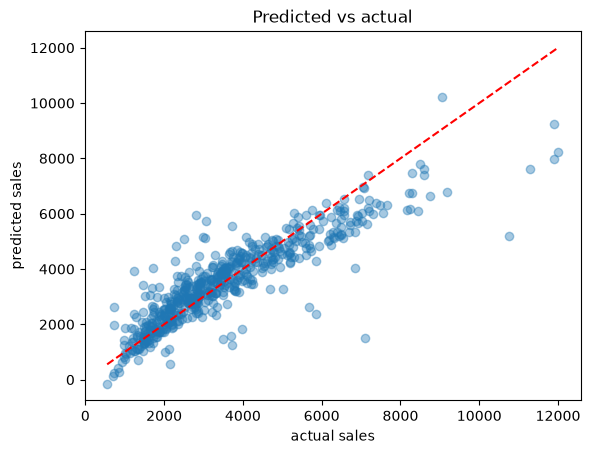

In [6]:
## predicted vs actual: points on the red line would be perfect
plt.scatter(y_test, pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('actual sales')
plt.ylabel('predicted sales')
plt.title('Predicted vs actual')
plt.show()

### Adding a feature and using cross-validation

More features can help, but a single train/test split is a noisy estimate. Cross-validation fits the model five times on different folds and averages, which is a more reliable score. Scaling before a regularized model (Ridge) keeps the penalty fair across features.

In [7]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

X = data[['QUANTITYORDERED', 'PRICEEACH', 'MSRP']]
y = data['SALES']

linear_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
ridge_scores = cross_val_score(ridge, X, y, cv=5, scoring='r2')

print('LinearRegression folds:', linear_scores.round(3), '| mean', round(linear_scores.mean(), 3))
print('Ridge            folds:', ridge_scores.round(3), '| mean', round(ridge_scores.mean(), 3))

LinearRegression folds: [0.686 0.811 0.775 0.758 0.726] | mean 0.751
Ridge            folds: [0.686 0.811 0.775 0.758 0.727] | mean 0.751


## Classification: predict the deal size

Same `fit` / `predict` shape, but the target is a category (`Small`, `Medium`, `Large`). Classification brings its own trap: if one class is rare, a model can score ~90% accuracy by just copying the majority class and still be useless. Always look past accuracy.

In [8]:
X = sales[['QUANTITYORDERED', 'PRICEEACH', 'MSRP']]
y = sales['DEALSIZE']

print(y.value_counts())
print('majority-class baseline:', round(y.value_counts(normalize=True).max(), 3))

DEALSIZE
Medium    1384
Small     1282
Large      157
Name: count, dtype: int64
majority-class baseline: 0.49


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## stratify keeps the class proportions in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print('accuracy:', round(accuracy_score(y_test, pred), 3))
print()
print(classification_report(y_test, pred))

accuracy: 0.903

              precision    recall  f1-score   support

       Large       0.83      0.48      0.61        31
      Medium       0.88      0.94      0.90       277
       Small       0.94      0.92      0.93       257

    accuracy                           0.90       565
   macro avg       0.88      0.78      0.82       565
weighted avg       0.90      0.90      0.90       565



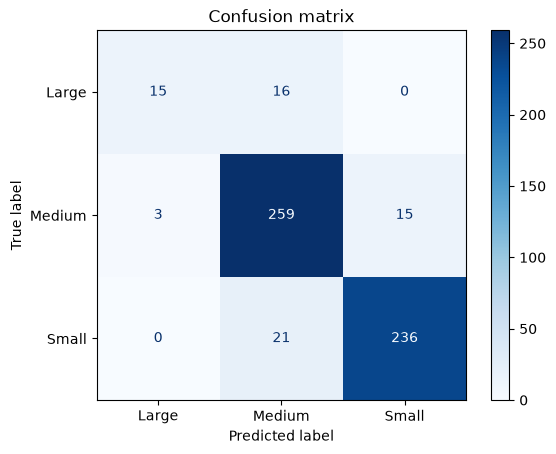

In [10]:
## which classes get confused with which?
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, cmap='Blues')
plt.title('Confusion matrix')
plt.show()

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'logistic': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    'tree': DecisionTreeClassifier(random_state=0),
    'forest': RandomForestClassifier(n_estimators=100, random_state=0),
}

for name, m in models.items():
    scores = cross_val_score(m, X, y, cv=5)
    print(f'{name:9} cv accuracy {scores.mean():.3f}')

logistic  cv accuracy 0.898
tree      cv accuracy 0.855


forest    cv accuracy 0.873


### What to remember

- `.fit` / `.predict` is the whole API; swapping models is one line.
- Split before you fit, and use cross-validation instead of one lucky split.
- Accuracy alone lies on imbalanced data. Read the per-class report and the confusion matrix.
- Scale features before regularized / distance-based models (`make_pipeline` keeps it clean).